In [14]:
%load_ext autoreload
%autoreload 2

import os

subj = "Subj3"

UNIQUE_VALUES_THRESHOLD = 200

exp = "exp_noise"
os.makedirs(f"{subj}/{exp}", exist_ok = True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import mne
import numpy
import pandas
import sklearn.metrics
import sklearn.preprocessing
import sklearn.decomposition

import SDA.topology
import SDA.analytics
import SDA.clustquality
import SDA.stageprocess

### Data

In [16]:
epochs = mne.read_epochs(f"{subj}/src/epochs_filt_rr-epo.fif")# .drop_channels(ch_names = [ 'IVEOG', 'IHEOG' ])
N_STAGES = int(numpy.loadtxt(f"{subj}/src/n_stages.txt"))
print('Stages: ', N_STAGES)

Reading d:\HSE\CourseProject\Subj3\src\epochs_filt_rr-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     500.00 ms
        0 CTF compensation matrices available
Not setting metadata
1180 matching events found
No baseline correction applied
0 projection items activated
Stages:  10


In [17]:
numpy.random.seed(42)
epochs = mne.simulation.add_noise(epochs, mne.compute_covariance(epochs), verbose = True, random_state = 42)

Reducing data rank from 40 -> 40
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 591180
[done]
Adding noise to 40/40 channels (40 channels in cov)


In [18]:
# epochs.average().plot_joint().savefig(f"{subj}/{exp}/eeg.svg")
data = epochs.get_data(copy = True)
print(data.shape)

(1180, 40, 501)


### Features

In [19]:
per_channel_folder = f"{subj}/{exp}/features/per_channel"
os.makedirs(per_channel_folder, exist_ok = True)
per_channel_extractor = SDA.topology.PerChannelFeatureExtractor(n_jobs = -1, folder = per_channel_folder, reduced = True)
per_channel_features = per_channel_extractor.extract(data)

dissimilarity_folder = f"{subj}/{exp}/features/dissimilarity"
os.makedirs(dissimilarity_folder, exist_ok = True)
dissimilarity_extractor = SDA.topology.DissimilarityFeatureExtractor(n_jobs = -1, folder = dissimilarity_folder, reduced = True)
dissimilarity_features = dissimilarity_extractor.extract(data)

overall_folder = f"{subj}/{exp}/features/overall"
os.makedirs(overall_folder, exist_ok = True)
overall_extractor = SDA.topology.OverallFeatureExtractor(n_jobs = -1, folder = overall_folder, reduced = True)
overall_features = overall_extractor.extract(data)

all_features = pandas.concat([
    per_channel_features,
    dissimilarity_features,
    overall_features
], axis = 1)

all_features.to_feather(f"{subj}/{exp}/features/all_features.feather")
display(all_features)

embedding params: 100%|██████████| 47200/47200 [02:15<00:00, 349.63it/s]


Saving embedding params to Subj3/exp_noise/features/per_channel/embedders_params.npy


point clouds: 100%|██████████| 47200/47200 [00:01<00:00, 29298.53it/s]


Calculating persistence
Diagrams: (47200, 192, 3)
Saving diagrams to Subj3/exp_noise/features/per_channel/diagrams.npy
Filtered diagrams: (47200, 186, 3)
Skipping Betti features
Calculating landscape features


 landscape: 100%|██████████| 47200/47200 [00:06<00:00, 6802.10it/s]


...

overall amplitudes: 100%|██████████| 13/13 [00:01<00:00,  7.19it/s]


Calculating lifetime features


overall lifetime: 100%|██████████| 1180/1180 [00:00<00:00, 2694.07it/s]


Features: (1180, 160)
Saving features to Subj3/exp_noise/features/overall/features.feather


,channel-0 landscape dim-1 max,channel-0 landscape dim-1 mean,channel-0 landscape dim-1 std,channel-0 landscape dim-1 sum,channel-0 landscape dim-1 norm-1,channel-0 landscape dim-1 norm-2,channel-0 landscape dim-2 max,channel-0 landscape dim-2 mean,channel-0 landscape dim-2 std,channel-0 landscape dim-2 sum,...,overall bd2 dim-2 std,overall bd2 dim-2 sum,overall bd2 dim-2 norm-1,overall bd2 dim-2 norm-2,overall bd2 dim-3 max,overall bd2 dim-3 mean,overall bd2 dim-3 std,overall bd2 dim-3 sum,overall bd2 dim-3 norm-1,overall bd2 dim-3 norm-2
0,0.000008,0.000001,0.000002,0.000129,0.000129,0.000026,0.000002,1.345926e-07,4.283143e-07,0.000013,...,0.000012,0.015851,0.015851,0.001871,0.000237,0.000227,0.000005,0.010665,0.010665,0.001556
1,0.000007,0.000001,0.000002,0.000105,0.000105,0.000023,0.000004,2.751354e-07,7.378596e-07,0.000028,...,0.000010,0.016497,0.016497,0.001920,0.000253,0.000237,0.000008,0.006153,0.006153,0.001207
2,0.000011,0.000001,0.000003,0.000147,0.000147,0.000031,0.000003,1.661870e-07,4.632758e-07,0.000017,...,0.000013,0.013996,0.013996,0.001752,0.000240,0.000224,0.000010,0.004704,0.004704,0.001027
3,0.000010,0.000001,0.000002,0.000114,0.000114,0.000027,0.000003,1.904234e-07,5.544191e-07,0.000019,...,0.000013,0.018562,0.018562,0.002017,0.000254,0.000228,0.000010,0.010034,0.010034,0.001514
4,0.000009,0.000001,0.000002,0.000102,0.000102,0.000025,0.000005,2.984977e-07,8.622444e-07,0.000030,...,0.000008,0.022519,0.022519,0.002220,0.000240,0.000228,0.000008,0.006849,0.006849,0.001251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1175,0.000011,0.000002,0.000003,0.000160,0.000160,0.000032,0.000003,2.346005e-07,6.417438e-07,0.000023,...,0.000012,0.022398,0.022398,0.002364,0.000304,0.000259,0.000013,0.011140,0.011140,0.001701
1176,0.000009,0.000002,0.000003,0.000185,0.000185,0.000033,0.000004,3.978621e-07,9.465125e-07,0.000040,...,0.000012,0.013922,0.013922,0.001846,0.000272,0.000256,0.000007,0.004090,0.004090,0.001023
1177,0.000016,0.000003,0.000004,0.000254,0.000254,0.000049,0.000005,4.535048e-07,1.063436e-06,0.000045,...,0.000011,0.019124,0.019124,0.002140,0.000276,0.000247,0.000013,0.004945,0.004945,0.001107
1178,0.000009,0.000001,0.000003,0.000145,0.000145,0.000031,0.000005,3.179347e-07,8.861398e-07,0.000032,...,0.000010,0.017896,0.017896,0.002082,0.000282,0.000253,0.000009,0.007350,0.007350,0.001366


In [20]:
features = sklearn.preprocessing.StandardScaler().fit_transform(all_features)
features = pandas.DataFrame(features, columns = all_features.columns)

features.to_feather(f"{subj}/{exp}/features/features.feather")
display(features)

numpy.save(f"{subj}/{exp}/features/features.npy", features.to_numpy())

,channel-0 landscape dim-1 max,channel-0 landscape dim-1 mean,channel-0 landscape dim-1 std,channel-0 landscape dim-1 sum,channel-0 landscape dim-1 norm-1,channel-0 landscape dim-1 norm-2,channel-0 landscape dim-2 max,channel-0 landscape dim-2 mean,channel-0 landscape dim-2 std,channel-0 landscape dim-2 sum,...,overall bd2 dim-2 std,overall bd2 dim-2 sum,overall bd2 dim-2 norm-1,overall bd2 dim-2 norm-2,overall bd2 dim-3 max,overall bd2 dim-3 mean,overall bd2 dim-3 std,overall bd2 dim-3 sum,overall bd2 dim-3 norm-1,overall bd2 dim-3 norm-2
0,-0.805979,-0.722448,-0.864605,-0.722448,-0.722448,-0.833460,-1.534474,-1.563309,-1.631940,-1.563309,...,-0.114644,-0.777015,-0.777015,-1.071242,-1.775517,-1.551144,-1.453490,0.996858,0.996858,0.658636
1,-1.290818,-1.177881,-1.255440,-1.177881,-1.177881,-1.247419,-0.055632,-0.445062,-0.401981,-0.445062,...,-0.625905,-0.646373,-0.646373,-0.916308,-1.144158,-1.114616,-0.505746,-0.284067,-0.284067,-0.346905
2,0.488735,-0.359190,-0.054752,-0.359190,-0.359190,-0.166586,-1.390681,-1.311925,-1.493023,-1.311925,...,0.210883,-1.152114,-1.152114,-1.444949,-1.653681,-1.681847,-0.086353,-0.695573,-0.695573,-0.866394
3,0.164859,-1.016029,-0.567210,-1.016029,-1.016029,-0.722270,-1.292695,-1.119084,-1.130871,-1.119084,...,0.452007,-0.228765,-0.228765,-0.608192,-1.105124,-1.500497,0.061442,0.817718,0.817718,0.538037
4,-0.513061,-1.237252,-0.844051,-1.237252,-1.237252,-0.979481,0.610249,-0.259177,0.092254,-0.259177,...,-1.152636,0.571354,0.571354,0.034502,-1.665288,-1.488194,-0.549866,-0.086373,-0.086373,-0.220372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1175,0.494311,-0.113068,0.014059,-0.113068,-0.113068,-0.037811,-0.914382,-0.767583,-0.783891,-0.767583,...,0.141474,0.546978,0.546978,0.488053,0.787317,-0.111063,0.878403,1.131874,1.131874,1.077215
1176,-0.305850,0.369836,-0.103284,0.369836,0.369836,0.062571,0.228374,0.531429,0.427088,0.531429,...,0.144374,-1.167057,-1.167057,-1.147808,-0.452978,-0.265630,-0.826614,-0.869844,-0.869844,-0.879459
1177,2.999877,1.716289,2.433017,1.716289,1.716289,2.206930,1.097194,0.974157,0.891677,0.974157,...,-0.194809,-0.115245,-0.115245,-0.218267,-0.296727,-0.641395,0.946689,-0.627199,-0.627199,-0.636034
1178,-0.401789,-0.397270,-0.092840,-0.397270,-0.397270,-0.204830,0.355442,-0.104524,0.187201,-0.104524,...,-0.647891,-0.363530,-0.363530,-0.402873,-0.037745,-0.362225,-0.383774,0.055886,0.055886,0.109801


In [21]:
os.makedirs(f"{subj}/{exp}/qsda", exist_ok = True)
qsda = SDA.QSDA(
    n_jobs = 1,
    qsda_n_jobs = 15,
    scores_folder = f"{subj}/{exp}/qsda",

    threshold = 1150,
    min_unique_values = UNIQUE_VALUES_THRESHOLD
)
best_features, scores = qsda.select(features)

best_features.to_feather(f"{subj}/{exp}/qsda/best_features.feather")
numpy.save(f"{subj}/{exp}/qsda/best_features.npy", features.to_numpy())
display(best_features)
display(scores)

scores: 100%|██████████| 4880/4880 [4:49:31<00:00,  3.56s/it]  

Using threshold 0.23


,channel-0 landscape dim-1 mean,channel-0 landscape dim-1 std,channel-0 landscape dim-1 sum,channel-0 landscape dim-1 norm-1,channel-0 landscape dim-1 norm-2,channel-0 silhouette-1 dim-1 mean,channel-0 silhouette-1 dim-1 sum,channel-0 silhouette-1 dim-1 norm-1,channel-0 silhouette-2 dim-1 mean,channel-0 silhouette-2 dim-1 sum,...,overall bd2 dim-1 max,overall bd2 dim-1 mean,overall bd2 dim-1 std,overall bd2 dim-1 sum,overall bd2 dim-1 norm-1,overall bd2 dim-1 norm-2,overall bd2 dim-2 max,overall bd2 dim-2 mean,overall bd2 dim-3 max,overall bd2 dim-3 mean
0,-0.722448,-0.864605,-0.722448,-0.722448,-0.833460,-0.799744,-0.799744,-0.799744,-0.712156,-0.712156,...,-1.527010,-1.520038,-0.847391,-1.558000,-1.558000,-1.723915,-1.190275,-1.495074,-1.775517,-1.551144
1,-1.177881,-1.255440,-1.177881,-1.177881,-1.247419,-0.912453,-0.912453,-0.912453,-1.091952,-1.091952,...,-1.654559,-1.562269,-0.926462,-1.736426,-1.736426,-1.868284,-1.467605,-1.360939,-1.144158,-1.114616
2,-0.359190,-0.054752,-0.359190,-0.359190,-0.166586,-0.361739,-0.361739,-0.361739,-0.288940,-0.288940,...,-1.199296,-1.595998,-0.458682,-1.198287,-1.198287,-1.504757,-1.114443,-1.565697,-1.653681,-1.681847
3,-1.016029,-0.567210,-1.016029,-1.016029,-0.722270,-0.172190,-0.172190,-0.172190,-0.173683,-0.173683,...,-1.258409,-1.536579,-0.579417,-0.649728,-0.649728,-1.111679,-1.192210,-1.580690,-1.105124,-1.500497
4,-1.237252,-0.844051,-1.237252,-1.237252,-0.979481,-0.768622,-0.768622,-0.768622,-0.693365,-0.693365,...,-1.759122,-1.759356,-1.814428,-0.703780,-0.703780,-1.257338,-1.730978,-1.568574,-1.665288,-1.488194
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1175,-0.113068,0.014059,-0.113068,-0.113068,-0.037811,0.330843,0.330843,0.330843,0.593018,0.593018,...,-0.185779,-0.109685,-0.565563,-0.181019,-0.181019,-0.161967,0.253908,-0.109558,0.787317,-0.111063
1176,0.369836,-0.103284,0.369836,0.369836,0.062571,-0.236816,-0.236816,-0.236816,-0.086682,-0.086682,...,-0.124806,-0.354980,-0.028286,-0.566251,-0.566251,-0.528339,-0.104820,-0.332494,-0.452978,-0.265630
1177,1.716289,2.433017,1.716289,1.716289,2.206930,0.915289,0.915289,0.915289,1.594032,1.594032,...,0.088593,-0.590791,-0.578679,-0.106420,-0.106420,-0.325843,-0.476144,-0.583625,-0.296727,-0.641395
1178,-0.397270,-0.092840,-0.397270,-0.397270,-0.204830,-0.001963,-0.001963,-0.001963,-0.115265,-0.115265,...,-0.329721,-0.223221,0.132401,-0.597051,-0.597051,-0.491562,-0.194805,-0.449009,-0.037745,-0.362225


,name,score,mean,variance,unique_values,normalized_score
0,channel-0 landscape dim-1 max,0.802142,-5.298963e-16,1.0,1180,0.208726
1,channel-0 landscape dim-1 mean,1.529740,2.408619e-17,1.0,1180,0.400832
2,channel-0 landscape dim-1 std,1.358563,2.167757e-16,1.0,1180,0.355636
3,channel-0 landscape dim-1 sum,1.529740,3.372067e-16,1.0,1180,0.400832
4,channel-0 landscape dim-1 norm-1,1.529740,3.372067e-16,1.0,1180,0.400832
...,...,...,...,...,...,...
4875,overall bd2 dim-3 mean,2.414571,-4.094653e-16,1.0,1180,0.634450
4876,overall bd2 dim-3 std,0.640502,4.817239e-17,1.0,1180,0.166049
4877,overall bd2 dim-3 sum,0.354322,1.249471e-16,1.0,1180,0.090490
4878,overall bd2 dim-3 norm-1,0.354322,1.249471e-16,1.0,1180,0.090490


### Results

In [22]:
features = numpy.load(f"{subj}/{exp}/qsda/best_features.npy")
features.shape

(1180, 4880)

#### Estimator

In [23]:
def analyze(all_features: pandas.DataFrame, n_components: int, folder: str):
    folder = f"{subj}/{exp}/results/{folder}"
    os.makedirs(folder, exist_ok = True)

    # Scale features
    all_features = sklearn.preprocessing.StandardScaler().fit_transform(all_features)
    print(all_features.shape)
    numpy.save(f"{folder}/all_features.npy", all_features)
    numpy.savetxt(f"{folder}/all_features_shape.txt", all_features.shape)

    # PCA
    pca = sklearn.decomposition.PCA(n_components = n_components, svd_solver = "full", random_state = 42)
    pca_features = pca.fit_transform(all_features)
    print(pca_features.shape)
    numpy.save(f"{folder}/pca_features.npy", pca_features)
    numpy.savetxt(f"{folder}/pca_features_shape.txt", pca_features.shape)
    
    print('Explained variance', round(pca.explained_variance_ratio_.sum(), 2))
    print([ round(x, 3) for x in pca.explained_variance_ratio_ ])
    numpy.savetxt(f"{folder}/explained_variance.txt", [ pca.explained_variance_ratio_.sum() ])
    numpy.savetxt(f"{folder}/explained_variance_ratios.txt", pca.explained_variance_ratio_)

    # SDA
    sda = SDA.SDA(n_jobs = 14, scale = False, verbose = True)
    results, df_st_edges = sda.apply(pca_features)
    
    results.to_csv(f"{folder}/results.csv")
    df_st_edges.to_csv(f"{folder}/df_st_edges.csv")

    # Analyze
    best_results = SDA.analytics.best_results(results, key = 'Avg-Silh')
    best_results.to_csv(f"{folder}/best_results.csv")
    
    best_result = SDA.analytics.best_result(results, key = 'Avg-Silh', n_stages = N_STAGES)
    best_result_df = pandas.DataFrame([ best_result ])
    best_result_df.to_csv(f"{folder}/best_result.csv")
    display(best_result_df)
    
    best_edges = numpy.array(best_result['St_edges'])
    numpy.savetxt(f"{folder}/best_edges.txt", best_edges, fmt = "%d", newline = ' ')
    display(best_edges)

    stage_timing = SDA.analytics.stage_timing(best_edges, epochs)
    stage_timing.to_csv(f"{folder}/stage_timing.csv")
    display(stage_timing)
    
    SDA.analytics.plot_stats(pca_features, epochs, best_result, df_st_edges).savefig(f"{folder}/stats.svg")

#### Традиционные признаки

(1180, 765)
(1180, 15)
Explained variance 0.72
[0.323, 0.095, 0.07, 0.043, 0.032, 0.025, 0.023, 0.02, 0.018, 0.016, 0.014, 0.012, 0.011, 0.01, 0.009]
Applying to 1180 samples with 15 features each


stage 2: 100%|██████████| 672/672 [00:08<00:00, 74.92it/s]


,St_len_min,K_nb_max,N_cl_max,Cl_cen,Len_min,St_edges,N_stages,Longest_stage,Shortest_stage,Avg_stage_length,Ward_dist,Cen_dist,Silh,Cal-Har,Dav-Bold,Avg-Silh,Avg-Cal-Har,Avg-Dav-Bold
0,40,40,20,Mode,40,"[0, 133, 175, 261, 458, 685, 827, 938, 1037, 1...",10,227,42,118.0,10633.480882,14.331052,-0.027117,64.582129,4.263643,0.111209,29.100237,2.643993


array([   0,  133,  175,  261,  458,  685,  827,  938, 1037, 1126, 1180])

,0,1,2,3,4,5,6,7,8,9
"Start-end time, sec","(8.5, 149.5)","(151.5, 198.5)","(200.5, 295.5)","(296.5, 516.5)","(517.5, 771.5)","(772.5, 924.5)","(926.5, 1046.5)","(1047.5, 1153.5)","(1154.5, 1247.5)","(1248.5, 1304.5)"
"Time length, sec",141.0,47.0,95.0,220.0,254.0,152.0,120.0,106.0,93.0,56.0
Number of epochs,133,42,86,197,227,142,111,99,89,54


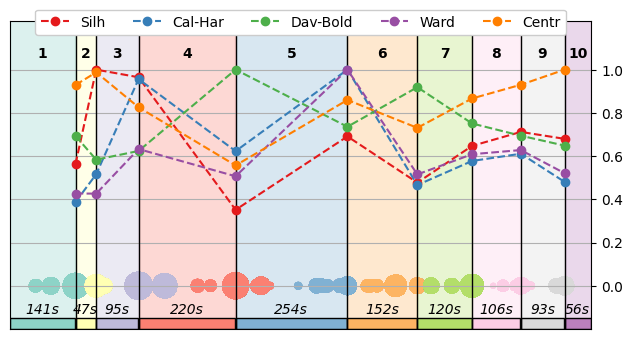

In [24]:
def read_traditional():
    df_ft_psd_loc_db = pandas.read_feather(f'{subj}/src/df_ft_psd_loc_db.feather')
    df_ft_psd_ind_loc_log = pandas.read_feather(f'{subj}/src/df_ft_psd_ind_loc_log.feather')
    df_ft_coh_ind_loc = pandas.read_feather(f'{subj}/src/df_ft_coh_ind_loc.feather')
    df_ft_plv_ind_loc = pandas.read_feather(f'{subj}/src/df_ft_plv_ind_loc.feather')

    result =  pandas.concat([
        df_ft_psd_loc_db,
        df_ft_psd_ind_loc_log,
        df_ft_coh_ind_loc,
        df_ft_plv_ind_loc
    ], axis = 1)

    if subj == "Subj2":
        result = result # [:-2]
    return result.to_numpy()

analyze(read_traditional(), 15, "traditional")

#### Топологические признаки + QSDA + PCA

(1180, 4880)
(1180, 15)
Explained variance 0.36
[0.139, 0.053, 0.023, 0.016, 0.016, 0.014, 0.013, 0.012, 0.011, 0.01, 0.01, 0.01, 0.01, 0.009, 0.009]
Applying to 1180 samples with 15 features each


stage 2: 100%|██████████| 672/672 [00:09<00:00, 71.65it/s]


,St_len_min,K_nb_max,N_cl_max,Cl_cen,Len_min,St_edges,N_stages,Longest_stage,Shortest_stage,Avg_stage_length,Ward_dist,Cen_dist,Silh,Cal-Har,Dav-Bold,Avg-Silh,Avg-Cal-Har,Avg-Dav-Bold
0,60,35,15,Median,40,"[0, 86, 195, 251, 673, 853, 898, 949, 1052, 11...",10,422,45,118.0,36129.501563,26.483842,-0.025163,42.575918,5.465068,0.0993,27.300134,2.931151


array([   0,   86,  195,  251,  673,  853,  898,  949, 1052, 1118, 1180])

,0,1,2,3,4,5,6,7,8,9
"Start-end time, sec","(8.5, 99.5)","(100.5, 219.5)","(220.5, 285.5)","(286.5, 758.5)","(759.5, 951.5)","(952.5, 1002.5)","(1003.5, 1059.5)","(1060.5, 1172.5)","(1173.5, 1239.5)","(1240.5, 1304.5)"
"Time length, sec",91.0,119.0,65.0,472.0,192.0,50.0,56.0,112.0,66.0,64.0
Number of epochs,86,109,56,422,180,45,51,103,66,62


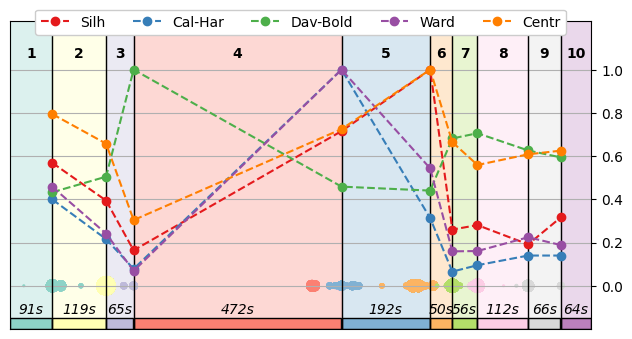

In [25]:
analyze(features, 15, "best_topological")

#### Традиционные и топологические вместе + PCA

(1180, 5645)
(1180, 15)
Explained variance 0.37
[0.128, 0.077, 0.025, 0.021, 0.015, 0.013, 0.012, 0.011, 0.01, 0.01, 0.01, 0.009, 0.009, 0.009, 0.008]
Applying to 1180 samples with 15 features each


stage 2: 100%|██████████| 672/672 [00:09<00:00, 73.42it/s]


,St_len_min,K_nb_max,N_cl_max,Cl_cen,Len_min,St_edges,N_stages,Longest_stage,Shortest_stage,Avg_stage_length,Ward_dist,Cen_dist,Silh,Cal-Har,Dav-Bold,Avg-Silh,Avg-Cal-Har,Avg-Dav-Bold
0,60,50,20,Mode,40,"[0, 132, 195, 251, 678, 843, 892, 949, 1038, 1...",10,427,49,118.0,39639.248274,28.313628,-0.011736,50.590542,5.146757,0.108473,26.324113,2.855728


array([   0,  132,  195,  251,  678,  843,  892,  949, 1038, 1118, 1180])

,0,1,2,3,4,5,6,7,8,9
"Start-end time, sec","(8.5, 147.5)","(149.5, 219.5)","(220.5, 285.5)","(286.5, 763.5)","(765.5, 941.5)","(942.5, 996.5)","(997.5, 1059.5)","(1060.5, 1154.5)","(1155.5, 1239.5)","(1240.5, 1304.5)"
"Time length, sec",139.0,70.0,65.0,477.0,176.0,54.0,62.0,94.0,84.0,64.0
Number of epochs,132,63,56,427,165,49,57,89,80,62


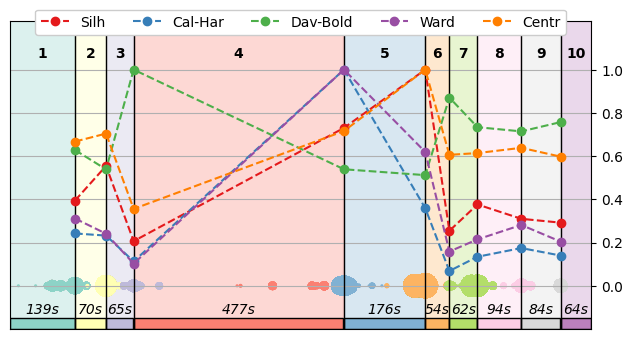

In [26]:
combined_features = numpy.concatenate([ read_traditional(), features ], axis = 1)
analyze(combined_features, 15, "combined")